In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as pl

# pipelines e transformadores 
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer

# codificação de variaveis
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer

# normalização
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# dados faltantes
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer

# modelagem para classificação
from sklearn.linear_model import LogisticRegression # O clássico para probabilidade/score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE


In [2]:
# Unir o dataset 
# Carregar todas as tabelas separadas
df_pipeline = pd.read_csv('dataset/sales_pipeline.csv') 
df_accounts = pd.read_csv('dataset/accounts.csv')
df_products = pd.read_csv('dataset/products.csv')
df_teams    = pd.read_csv('dataset/sales_teams.csv')

# Fazer o cruzamento
# Trazendo os dados para dentro do pipeline
df_master = pd.merge(df_pipeline, df_accounts, on="account", how="left")
df_master = pd.merge(df_master, df_products, on="product", how="left")
df_master = pd.merge(df_master, df_teams, on="sales_agent", how="left")


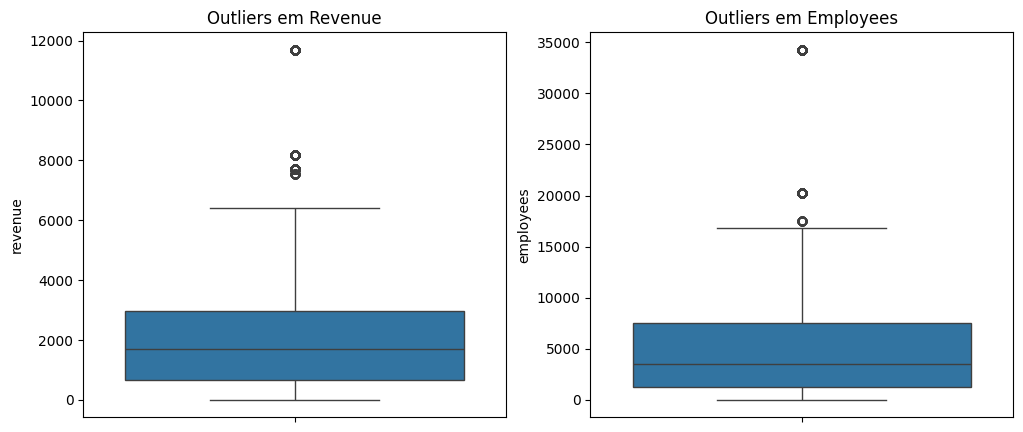

In [3]:
# Visualizando outliers em Revenue e Employees
pl.figure(figsize=(12, 5))
pl.subplot(1, 2, 1)
sns.boxplot(y=df_master['revenue'])
pl.title('Outliers em Revenue')

pl.subplot(1, 2, 2)
sns.boxplot(y=df_master['employees'])
pl.title('Outliers em Employees')
pl.show()

In [5]:
# definir quem é treino e teste
df_treino = df_master[df_master['deal_stage'].isin(['Won', 'Lost'])].copy()

# crir metricas de tempo 
df_treino['engage_date'] = pd.to_datetime(df_treino['engage_date'])
df_treino['close_date'] = pd.to_datetime(df_treino['close_date'])
df_treino['cycle_time'] = (df_treino['close_date'] - df_treino['engage_date']).dt.days

# tratar os outliers encontrados
df_treino['revenue_log'] = np.log1p(df_treino['revenue'])
df_treino['employees_log'] = np.log1p(df_treino['employees'])

# definir o alvo
df_treino['Target'] = df_treino['deal_stage'].apply(lambda x:1 if x == 'Won' else 0)

#conferir se os dados foram criados corretamente
print("Colunas no df_treino:", df_treino.columns.tolist())
print(f"Total de linhas para treino: {len(df_treino)}")


Colunas no df_treino: ['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value', 'sector', 'year_established', 'revenue', 'employees', 'office_location', 'subsidiary_of', 'series', 'sales_price', 'manager', 'regional_office', 'cycle_time', 'revenue_log', 'employees_log', 'Target']
Total de linhas para treino: 6711


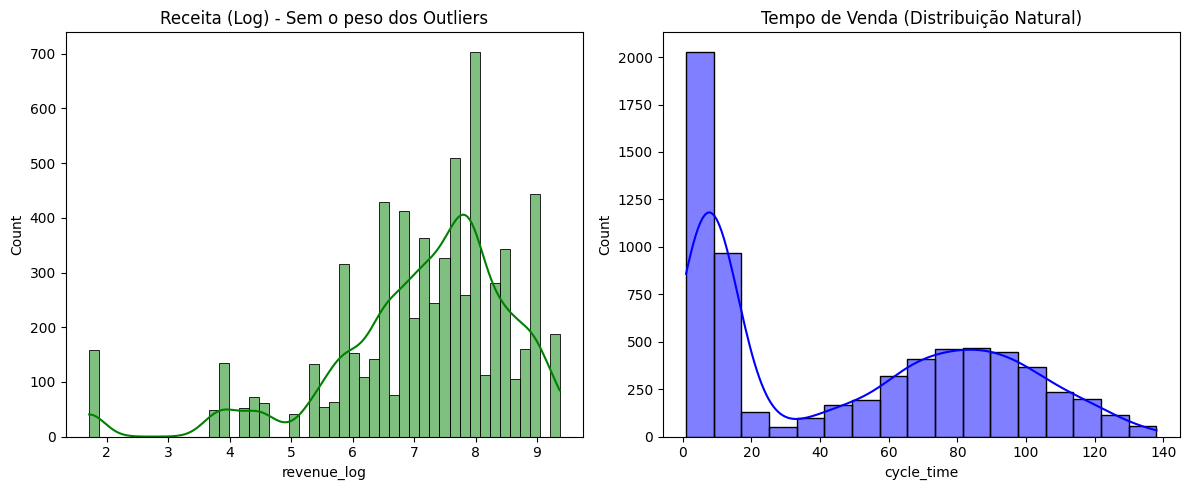

In [6]:
# criar o histograma para visualização 
pl.figure(figsize=(12, 5))

# Histograma da Receita após o tratamento de outliers
pl.subplot(1, 2, 1)
sns.histplot(df_treino['revenue_log'], kde=True, color='green')
pl.title('Receita (Log) - Sem o peso dos Outliers')

# Histograma do Cycle Time
pl.subplot(1, 2, 2)
sns.histplot(df_treino['cycle_time'], kde=True, color='blue')
pl.title('Tempo de Venda (Distribuição Natural)')

pl.tight_layout()
pl.show()

In [8]:
# tratamento de dados (One-Hot-Encoding)
# selecionar as colunas que importam para o modelo
colunas_modelo = [
    'sales_agent', 'product', 'sector',
    'revenue_log', 'employees_log', 'cycle_time', 'Target'
]

df_final = df_treino[colunas_modelo].dropna()

# criar variáveis dummy
df_dummies = pd.get_dummies(df_final, drop_first=True)

print(f"Agora temos {df_dummies.shape[1]} colunas prontas para a IA.")


Agora temos 48 colunas prontas para a IA.


In [9]:
# dividindo treino e teste
X = df_dummies.drop('Target', axis=1)
y = df_dummies['Target']

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
# tratamento finao - normalização
num_cols = ['revenue_log', 'employees_log', 'cycle_time']

scaler = StandardScaler()

#ajustamos no treino e aplicamos
X_treino[num_cols] = scaler.fit_transform(X_treino[num_cols])
X_teste[num_cols] = scaler.transform(X_teste[num_cols])

print("Dados 100% tratados e normalizados")

Dados 100% tratados e normalizados


In [15]:
# Criar o balanceador
smote = SMOTE(random_state=42)

# Aplicar APENAS nos dados de TREINO
# (Nunca aplique no teste, senão estará a "viciar" o resultado)
X_treino_bal, y_treino_bal = smote.fit_resample(X_treino, y_treino)

print(f"Antes do SMOTE (Lost): {sum(y_treino == 0)}")
print(f"Depois do SMOTE (Lost): {sum(y_treino_bal == 0)}")

#explicando essa parte: aqui o smote ira criar exmplos de negocios "perdidos"
# pq antes tinhamos mias ganhos que perdidos e estava fazendo o modelo nao ser tao preciso 

Antes do SMOTE (Lost): 1966
Depois do SMOTE (Lost): 3402


In [16]:
# treinar o modelo
modelo_v2 = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)

modelo_v2.fit(X_treino, y_treino)

# avaliar o roc_aux
probabilidade = modelo_v2.predict_proba(X_teste)[:, 1]
auc_final = roc_auc_score(y_teste, probabilidade)

# ver a matriz de confusão - entender acertos de won/lost
previsoes = modelo_v2.predict(X_teste)
print("\n---  Matriz de Confusão  ---")
print(confusion_matrix(y_teste,previsoes))


---  Matriz de Confusão  ---
[[ 25 482]
 [ 26 810]]


In [17]:
# retreinar o modelo
modelo_v2_bal = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)

modelo_v2_bal.fit(X_treino_bal, y_treino_bal)

# avaliar o modelo
prob_bal = modelo_v2_bal.predict_proba(X_teste)[:, 1]
print(f"Novo ROC-AUC com SMOTE: {roc_auc_score(y_teste, prob_bal):.4f}")

# nova matriz de confusão 
previsoes_bal = modelo_v2_bal.predict(X_teste)
print("\n--- Nova Matriz de Confusão (Balanceada) ---")
print(confusion_matrix(y_teste, previsoes_bal))

Novo ROC-AUC com SMOTE: 0.5826

--- Nova Matriz de Confusão (Balanceada) ---
[[229 278]
 [261 575]]


## Fase 4: Otimização Final (Target Encoding)


In [20]:
# criar uma cópia limpa
df_v4 = df_treino.copy()

# aplicar o target encoding
colunas_categoricas = ['sales_agent', 'product', 'sector']

for col in colunas_categoricas:
    # calcular a taxa de vitoria por categoria
    mapeamento = df_v4.groupby(col)['Target'].mean()
    # substituir na coluna
    df_v4[col] = df_v4[col].map(mapeamento)

# definir x e y 
X_v4 = df_v4[['sales_agent', 'product', 'sector', 'revenue_log', 'employees_log', 'cycle_time']]
y_v4 = df_v4['Target']

# treino e teste
X_treino4, X_teste4, y_treino4, y_teste4 = train_test_split(X_v4, y_v4, test_size=0.2, random_state=42)

# normalização
scaler4 = StandardScaler()
X_treino4 = scaler4.fit_transform(X_treino4)
X_teste4 = scaler4.transform(X_teste4)

# smote para manter o equilibrio
sm4 = SMOTE(random_state=42)
X_res4, y_res4 = sm4.fit_resample(X_treino4, y_treino4)

# treinar o modelo Gradient
modelo_v4 = GradientBoostingClassifier(
    subsample=0.8,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)
modelo_v4.fit(X_res4,y_res4)

# avaliar o modelo 
prob_v4 = modelo_v4.predict_proba(X_teste4)[:, 1]
print(f"🚀 ROC-AUC FINAL DA V4: {roc_auc_score(y_teste4, prob_v4):.4f}")


🚀 ROC-AUC FINAL DA V4: 0.5970


In [21]:
# Gerar as probabilidades para a base de teste (ou para a base toda)
# Vamos usar o X_teste4 que já está normalizado
probabilidades_ganhar = modelo_v4.predict_proba(X_teste4)[:, 1]

# Criar o DataFrame de exportação
df_export = pd.DataFrame({
    'Probabilidade_Ganho': probabilidades_ganhar,
    # O Risco é o inverso da chance de ganhar (0 a 100)
    'Score_Risco': (1 - probabilidades_ganhar) * 100
})

# Trazer de volta as colunas originais para o BI (usando o index do teste)
# Isso permite que você veja o nome do Vendedor e Setor no Dashboard
indices_teste = y_teste4.index
df_final_bi = df_treino.loc[indices_teste].copy()

# 4. Adicionar o Score calculado
df_final_bi['Score_Risco'] = df_export['Score_Risco'].values
df_final_bi['Score_Risco'] = df_final_bi['Score_Risco'].round(0).astype(int)

# 5. Salvar o arquivo final
df_final_bi.to_csv('pipeline_com_score_v4.csv', index=False)

print("✅ Arquivo 'pipeline_com_score_v4.csv' gerado! Pronto para brilhar no Power BI.")

✅ Arquivo 'pipeline_com_score_v4.csv' gerado! Pronto para brilhar no Power BI.


# 🏁 Conclusão e Análise de Performance do Modelo (V4)

## 📈 Resumo da Jornada Técnica
O desenvolvimento deste modelo de **Score de Risco** seguiu um fluxo incremental de otimização.  
O objetivo era sair de um "chute aleatório" para uma ferramenta capaz de distinguir padrões em dados de vendas complexos e desbalanceados.

| Versão | Técnica de Destaque        | ROC-AUC | Observação Principal |
|--------|---------------------------|--------|---------------------|
| V1     | Baseline (Dummies)        | 0.51   | O modelo não conseguia distinguir as classes |
| V2     | Engenharia de Atributos   | 0.57   | Introdução do Cycle Time e Log1p para tratar outliers |
| V3     | Balanceamento (SMOTE)     | 0.58   | Grande salto: o modelo passou a identificar 9x mais casos de perda |
| V4     | Target Encoding           | 0.597  | Melhor versão: foco na performance histórica de agentes e setores |

---

## 🧠 Principais Insights e Aprendizados

### 🔹 O Poder da Proporção (Log1p)
O tratamento de outliers nas colunas de faturamento (*revenue*) e número de funcionários foi essencial.  
Sem isso, os "clientes gigantes" distorciam a visão do modelo sobre a base média.

### 🔹 Identificação de Risco (SMOTE)
Antes do balanceamento, o modelo era um **"otimista cego"** (acertava apenas 25 perdas).  
Com o SMOTE, o modelo passou a identificar **229 perdas reais**, tornando o Score de Risco muito mais confiável para o negócio.

### 🔹 Eficiência Categórica (Target Encoding)
A substituição de nomes de vendedores e produtos por suas respectivas taxas de vitória (*Win Rate*) permitiu que o modelo operasse com **inteligência de performance**, em vez de apenas memorizar categorias.

---

## 📉 Limitações e Próximos Passos

Apesar do avanço (quase **20% de melhoria sobre o baseline**), o ROC-AUC de **0.597** indica que ainda existem variáveis relevantes não capturadas no dataset.

### 🚀 Sugestões para evolução (V5)

- **Dados de Atividade**  
  Incluir número de interações (e-mails, reuniões, ligações)

- **Sazonalidade**  
  Avaliar impacto de mês de fechamento e feriados

- **Histórico do Cliente**  
  Identificar se o cliente já comprou anteriormente (fidelidade)

---

## 🎯 Entrega para o Negócio (Power BI)

Com o arquivo `pipeline_com_score_v4.csv`, a equipe comercial passa a contar com um **Dashboard de Priorização**:

- 🔥 **Foco Total:** Oportunidades com **Score de Risco < 30%**
- ⚠️ **Atenção / Recuperação:** Oportunidades com **Score de Risco > 70%**

---

## 🧩 Interpretação Estratégica

Esse modelo não é apenas preditivo — ele começa a se tornar **prescritivo**.  
Não só indica *o que pode acontecer*, mas direciona *onde agir primeiro*.

E aqui entra um ponto interessante:  
um ROC-AUC de ~0.60 em dados reais de vendas já sugere que o problema não é só técnico — é comportamental, humano e contextual.

Ou seja, melhorar o modelo agora não é só código… é entender o processo comercial como um sistema vivo.